      definition  pre_count  pre_n  pre_percent  pre_ci_low  pre_ci_high  post_count  post_n  post_percent  post_ci_low  post_ci_high  difference_points  diff_ci_low  diff_ci_high  chi_square  p_value
          GPT-4o        712   7650       9.3072      8.6764       9.9788         587    4887       12.0115      11.1297       12.9529             2.7043       1.5842        3.8244     23.4801   0.0000
Gemini-2.0-Flash        506   7650       6.6144      6.0789       7.1934         366    4887        7.4893       6.7842        8.2611             0.8749      -0.0497        1.7994      3.5269   0.0604
    GPT ∩ Gemini        413   7650       5.3987      4.9143       5.9279         306    4887        6.2615       5.6160        6.9757             0.8628       0.0156        1.7101      4.1064   0.0427
    GPT ∪ Gemini        805   7650      10.5229      9.8550      11.2304         647    4887       13.2392      12.3178       14.2184             2.7163       1.5434        3.8892     21.4862   0.

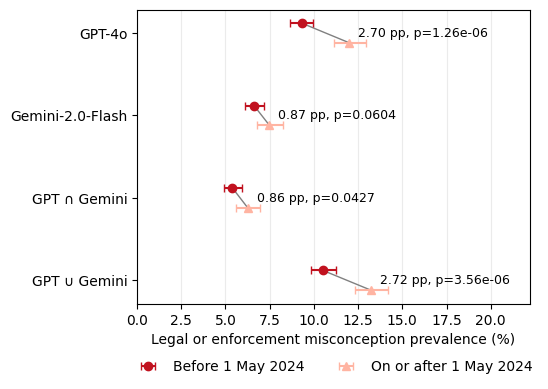

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportion_confint, confint_proportions_2indep

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# data is provided in the dataset folder
DATA_DIR = '.'
GPT_FILE = 'gpt.csv'
GEMINI_FILE = 'gemini.csv'
LLAMA_FILE = 'llama.csv'
CUTOFF = pd.Timestamp('2024-05-01', tz='UTC')

def parse_labels(value):
    labels = sorted({int(x) for x in re.findall(r'[1-5]', str(value))})
    substantive = [x for x in labels if x in (1, 2, 3, 4)]
    if substantive:
        return substantive
    return [5]

def add_label_columns(df, prefix):
    labels = df['writing'].map(parse_labels)
    for label in (1, 2, 3, 4, 5):
        df[f'{prefix}_L{label}'] = labels.map(lambda xs, label=label: label in xs)
    df[f'{prefix}_any'] = df[[f'{prefix}_L{x}' for x in (1, 2, 3, 4)]].any(axis=1)
    df[f'{prefix}_legal_enforcement'] = df[[f'{prefix}_L2', f'{prefix}_L3']].any(axis=1)
    return df

def proportion_row(name, indicator, post_mask):
    n_pre = int((~post_mask).sum())
    n_post = int(post_mask.sum())
    x_pre = int(indicator[~post_mask].sum())
    x_post = int(indicator[post_mask].sum())
    table = np.array([[x_pre, n_pre - x_pre], [x_post, n_post - x_post]])
    chi2, p_value, _, _ = chi2_contingency(table, correction=False)
    ci_pre = proportion_confint(x_pre, n_pre, method='wilson')
    ci_post = proportion_confint(x_post, n_post, method='wilson')
    diff_ci = confint_proportions_2indep(x_post, n_post, x_pre, n_pre, method='wald')
    return {
        'definition': name,
        'pre_count': x_pre,
        'pre_n': n_pre,
        'pre_percent': 100 * x_pre / n_pre,
        'pre_ci_low': 100 * ci_pre[0],
        'pre_ci_high': 100 * ci_pre[1],
        'post_count': x_post,
        'post_n': n_post,
        'post_percent': 100 * x_post / n_post,
        'post_ci_low': 100 * ci_post[0],
        'post_ci_high': 100 * ci_post[1],
        'difference_points': 100 * (x_post / n_post - x_pre / n_pre),
        'diff_ci_low': 100 * diff_ci[0],
        'diff_ci_high': 100 * diff_ci[1],
        'chi_square': chi2,
        'p_value': p_value,
    }

def cohen_kappa(a, b):
    a = np.asarray(a).astype(int)
    b = np.asarray(b).astype(int)
    p_o = np.mean(a == b)
    p_yes_a = np.mean(a == 1)
    p_yes_b = np.mean(b == 1)
    p_e = p_yes_a * p_yes_b + (1 - p_yes_a) * (1 - p_yes_b)
    if np.isclose(1 - p_e, 0):
        return np.nan
    return (p_o - p_e) / (1 - p_e)

def main():
    gpt = pd.read_csv(f'{DATA_DIR}/{GPT_FILE}')
    gemini = pd.read_csv(f'{DATA_DIR}/{GEMINI_FILE}')
    llama = pd.read_csv(f'{DATA_DIR}/{LLAMA_FILE}')

    base = gpt[['body', 'communityName', 'createdAt', 'numberOfreplies', 'upVotes']].copy()
    base['date'] = pd.to_datetime(base['createdAt'], utc=True)
    base['post_may_2024'] = base['date'] >= CUTOFF

    for name, df in [('gpt', gpt), ('gemini', gemini), ('llama', llama)]:
        add_label_columns(df, name)
        for col in [f'{name}_L{x}' for x in (1, 2, 3, 4, 5)] + [f'{name}_any', f'{name}_legal_enforcement']:
            base[col] = df[col].astype(bool)

    definitions = {
        'GPT-4o': base['gpt_legal_enforcement'],
        'Gemini-2.0-Flash': base['gemini_legal_enforcement'],
        'GPT ∩ Gemini': base['gpt_legal_enforcement'] & base['gemini_legal_enforcement'],
        'GPT ∪ Gemini': base['gpt_legal_enforcement'] | base['gemini_legal_enforcement'],
    }

    rows = [proportion_row(name, indicator, base['post_may_2024']) for name, indicator in definitions.items()]
    results = pd.DataFrame(rows)
    results.to_csv('robustness.csv', index=False)

    agreement_rows = []
    pairs = [('GPT-4o', 'gpt'), ('Gemini-2.0-Flash', 'gemini'), ('LLaMA-3.2B', 'llama')]
    for i in range(len(pairs)):
        for j in range(i + 1, len(pairs)):
            label_a, key_a = pairs[i]
            label_b, key_b = pairs[j]
            a = base[f'{key_a}_legal_enforcement']
            b = base[f'{key_b}_legal_enforcement']
            agreement_rows.append({
                'model_a': label_a,
                'model_b': label_b,
                'agreement_percent': 100 * np.mean(a == b),
                'kappa': cohen_kappa(a, b),
                'discordant_records': int(np.sum(a != b)),
            })
    pd.DataFrame(agreement_rows).to_csv('model_agreement.csv', index=False)

    fig, ax = plt.subplots(figsize=(5.5,4.5))
    y_positions = np.arange(len(results))[::-1]
    offset = 0.12

    # Added zorder=3 to keep markers in front
    ax.errorbar(results['pre_percent'], y_positions + offset,
                xerr=[results['pre_percent'] - results['pre_ci_low'], results['pre_ci_high'] - results['pre_percent']],
                fmt='o', capsize=3, label='Before 1 May 2024', color='#c1121f', zorder=3)

    ax.errorbar(results['post_percent'], y_positions - offset,
                xerr=[results['post_percent'] - results['post_ci_low'], results['post_ci_high'] - results['post_percent']],
                fmt='^', capsize=3, label='On or after 1 May 2024', color='#ffb4a2', zorder=3)

    for idx, row in results.iterrows():
        y = y_positions[idx]

        # Added color='gray' and zorder=2 to keep lines behind markers
        ax.plot([row['pre_percent'], row['post_percent']], [y + offset, y - offset],
                linewidth=1, color='gray', zorder=2)

        ax.text(max(row['pre_percent'], row['post_percent']) + 0.5, y,
                f"{row['difference_points']:.2f} pp, p={row['p_value']:.3g}", va='center', fontsize=9)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(results['definition'])
    ax.set_xlabel('Legal or enforcement misconception prevalence (%)')
    ax.set_title('')
    ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, -0.28), ncol=2)
    ax.grid(axis='x', alpha=0.25)
    ax.set_xlim(0, max(results['post_ci_high'].max(), results['pre_ci_high'].max()) + 8)
    fig.tight_layout(rect=[0, 0.08, 1, 1])


    fig.savefig('robustness.pdf', format='pdf', bbox_inches='tight')

    print(results.round(4).to_string(index=False))
    print('\nModel agreement for legal or enforcement indicator')
    print(pd.DataFrame(agreement_rows).round(4).to_string(index=False))

if __name__ == '__main__':
    main()
